# Flight Data Analysis: Sensor Reliability & Spectral Characterisation During Landing

This notebook presents a personal analysis of longitudinal acceleration data recorded during an aircraft landing sequence. The goal is to assess the reliability of two independent accelerometers — a locally mounted galley-area IMU (Sensor A) and the aircraft's pre-installed center-of-gravity accelerometer (Sensor B) — using spectral methods, and to extract a provisional touchdown timestamp for downstream refinement.

**Dataset:** `part1.csv` — flight test data recorded on board Cranfield University’s Saab 340, covering approximately 8 minutes around the time of landing. The columns used are:
- `Analogue Input Timestamp [s]` — time axis
- `Longitudinal Acceleration [g]` — Sensor A (Galley IMU, local measurement)
- `AC Longitudinal Acceleration [g]` — Sensor B (aircraft CoG accelerometer, global measurement)

**Analysis pipeline:**
1. QA/QC and resampling to a uniform time base
2. Touchdown localisation from accelerometer data
3. Welch PSD, inter-sensor coherence, and spectral ratios on the post-touchdown rollout
4. Band-limited RMS quantification
5. Time-frequency spectrogram
6. Export of provisional touchdown timestamp for CPD-based refinement


## 0) Environment & Imports

Standard scientific stack. Run once before executing the rest of the notebook.


In [12]:
!pip install numpy pandas matplotlib 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from pathlib import Path

# Set matplotlib style for reproducible, clean output
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['axes.grid.which'] = 'both'  # minor & major gridlines
plt.rcParams['font.size'] = 10

Access is denied.


## 1) Welch Parameter Configuration

The three values below drive every spectral calculation in this notebook (PSD, coherence, spectral ratio, and spectrogram). They are set once here and propagated automatically, ensuring full consistency across all analyses.

- **`TARGET_SEG_S`** — target segment duration (seconds). Larger values improve frequency resolution but reduce the number of averages (higher PSD variance).
- **`MIN_SEGMENTS`** — minimum number of Welch segments required. This acts as a safety floor on variance reduction.
- **`MIN_NPERSEG`** — minimum samples per segment. Guards against overly coarse resolution.

These values were chosen to balance resolution and variance given the ~115 s post-touchdown window available. After completing a first full run, the parameters can be revisited to assess sensitivity.


In [13]:
TARGET_SEG_S   = 8.0   # seconds per segment
MIN_SEGMENTS   = 8     # minimum number of segments
MIN_NPERSEG    = 128   # minimum nperseg



assert TARGET_SEG_S not in (None, 'EDIT', ''), 'You must set TARGET_SEG_S'
assert isinstance(MIN_SEGMENTS, (int, np.integer)) and MIN_SEGMENTS>=4, 'MIN_SEGMENTS must be >=4'
assert isinstance(MIN_NPERSEG, (int, np.integer)) and MIN_NPERSEG>=64, 'MIN_NPERSEG must be >=64'


## 2) Data Loading & QA/QC

The CSV is loaded and the three relevant columns are identified. A quick overview of the dataset (shape, statistics, first rows) is printed before any processing begins.


In [14]:

# Load CSV file
csv_path = Path(r"part1.csv")
df = pd.read_csv(csv_path)

# Column names 
t_col = 'Analogue Input Timestamp [s]'
a1_col = 'Longitudinal Acceleration [g]'  # Sensor A (Galley IMU, local)
a2_col = 'AC Longitudinal Acceleration [g]'  # Sensor B (Center of Gravity, global)

print("Dataset Overview")
print("="*60)
print(f"Rows: {len(df)}")
print(f"Columns: {list(df.columns)}")
print(f"\nFirst 5 rows:")
print(df[[t_col, a1_col, a2_col]].head())
print(f"\nBasic statistics:")
print(df[[a1_col, a2_col]].describe())


Dataset Overview
Rows: 25211
Columns: ['Analogue Input Timestamp [s]', 'Longitudinal Acceleration [g]', 'AC Longitudinal Acceleration [g]']

First 5 rows:
   Analogue Input Timestamp [s]  Longitudinal Acceleration [g]  \
0                     2834.2848                         0.0455   
1                     2834.3053                         0.0796   
2                     2834.3258                         0.0423   
3                     2834.3463                         0.0682   
4                     2834.3668                         0.0600   

   AC Longitudinal Acceleration [g]  
0                            0.0570  
1                            0.0566  
2                            0.0570  
3                            0.0576  
4                            0.0575  

Basic statistics:
       Longitudinal Acceleration [g]  AC Longitudinal Acceleration [g]
count                   25211.000000                      25211.000000
mean                        0.000332                       

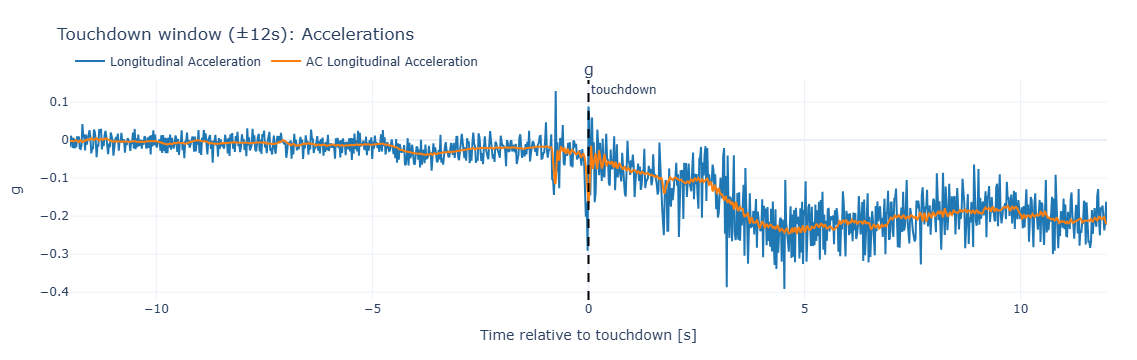

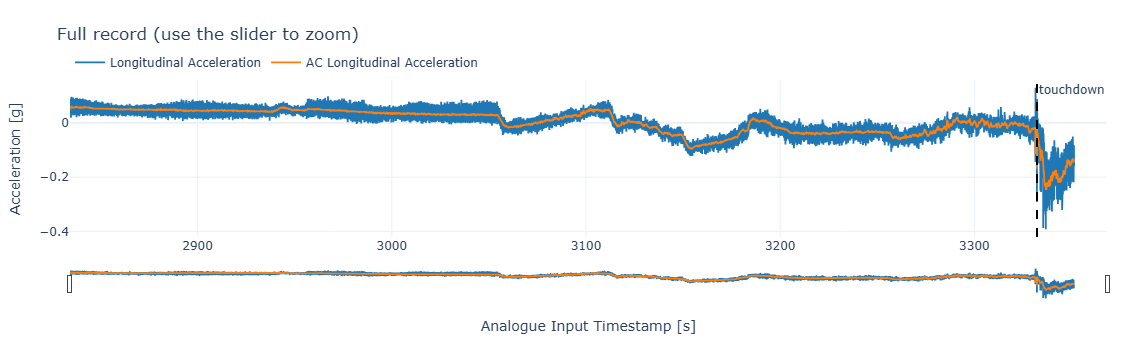

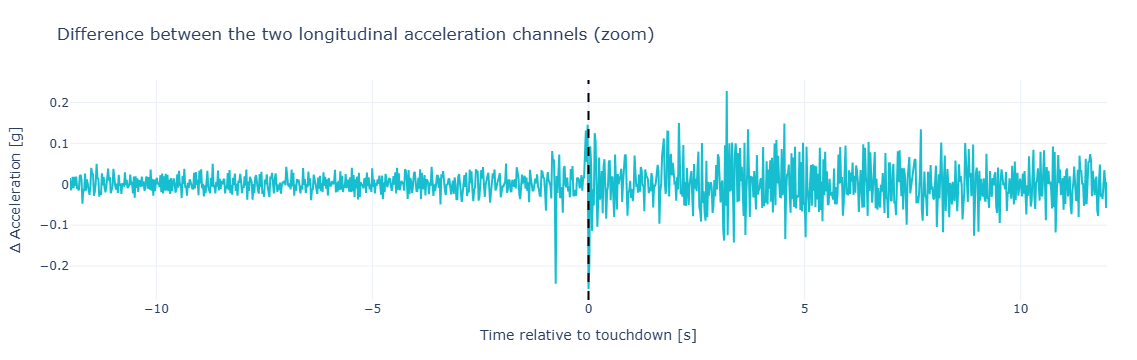

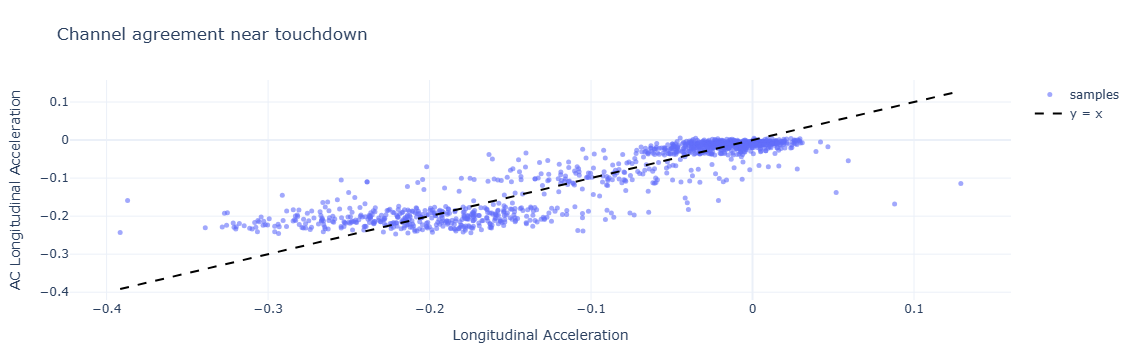

Estimated touchdown at 3332.255 s (max jerk heuristic)


In [15]:
import pandas as pd
import numpy as np
import re

import plotly.graph_objects as go
from plotly.subplots import make_subplots
# this was added later for IVHM students to visualise the data. This uses different definitions. 
# =========================
# Load data
# =========================
fp = "part1.csv"
df = pd.read_csv(fp)

# Identify time column (fallback: first column)
time_candidates = [c for c in df.columns if re.search(r"time|timestamp", c, re.I)]
time_col = time_candidates[0] if time_candidates else df.columns[0]

df = df.copy()
df[time_col] = pd.to_numeric(df[time_col], errors="coerce")
df = df.dropna(subset=[time_col]).sort_values(time_col)

# Numeric parameter columns
param_cols = [c for c in df.columns if c != time_col]
for c in param_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# =========================
# Touchdown estimation (heuristic)
# - uses a combined "jerk" score across available channels
# =========================
t = df[time_col].to_numpy()
signals = df[param_cols].to_numpy(dtype=float)

jerks = []
for k in range(signals.shape[1]):
    s = signals[:, k]
    s_interp = pd.Series(s).interpolate(limit_direction="both").to_numpy()
    jerks.append(np.abs(np.gradient(s_interp, t)))

score = np.nanmean(np.vstack(jerks), axis=0) if jerks else np.zeros_like(t)

dt = np.nanmedian(np.diff(t))
win = int(max(5, round(0.5 / dt))) if np.isfinite(dt) and dt > 0 else 25
roll_std = pd.Series(score).rolling(win, center=True, min_periods=max(3, win // 2)).std().to_numpy()

touch_idx = int(np.nanargmax(score + np.nan_to_num(roll_std)))
t0 = float(t[touch_idx])

df["t_rel_s"] = df[time_col] - t0
touch_label = f"Estimated touchdown at {t0:.3f} s (max jerk heuristic)"

# Window around touchdown for detailed views
W = 12.0  # seconds
df_w = df[(df["t_rel_s"] >= -W) & (df["t_rel_s"] <= W)].copy()

# =========================
# Helpers: units, grouping, labels
# =========================
def col_unit(name: str) -> str:
    m = re.search(r"\[([^\]]+)\]", name)
    return m.group(1).strip() if m else ""

def col_group(name: str) -> str:
    n = name.lower()
    if "accel" in n or "acceleration" in n:
        return "Accelerations"
    if "rate" in n or "gyro" in n:
        return "Angular rates"
    if "alt" in n:
        return "Altitudes"
    if "speed" in n or "spd" in n or "mach" in n:
        return "Speeds"
    if "angle" in n or "pitch" in n or "roll" in n or "yaw" in n:
        return "Attitudes / angles"
    if "thrust" in n or "n1" in n or "n2" in n or "rpm" in n:
        return "Engines"
    if "flap" in n or "gear" in n or "brake" in n:
        return "Controls / config"
    return "Other"

def pretty_label(c: str) -> str:
    c2 = re.sub(r"\s*\[[^\]]+\]\s*$", "", c).strip()
    return c2

# Complementary colour pairs (cycled)
colour_pairs = [
    ("#1f77b4", "#ff7f0e"),  # blue / orange
    ("#17becf", "#e377c2"),  # teal / magenta
    ("#2ca02c", "#9467bd"),  # green / purple
    ("#1f3b73", "#f2c14e"),  # navy / gold
]

# =========================
# Plot function: grouped-by-unit rows (correct axes per unit)
# =========================
def plot_group_zoom(df_in: pd.DataFrame, cols: list[str], title: str):
    units = {}
    for c in cols:
        units.setdefault(col_unit(c) or " ", []).append(c)

    fig = make_subplots(
        rows=len(units), cols=1, shared_xaxes=True, vertical_spacing=0.08,
        subplot_titles=[f"{u}" if u.strip() else " " for u in units.keys()],
    )

    color_i = 0
    for r, (u, ucols) in enumerate(units.items(), start=1):
        for j, c in enumerate(ucols):
            pair = colour_pairs[(color_i // 2) % len(colour_pairs)]
            color = pair[j % 2] if len(ucols) == 2 else pair[j % 2]
            color_i += 1

            fig.add_trace(
                go.Scatter(
                    x=df_in["t_rel_s"],
                    y=df_in[c],
                    mode="lines",
                    name=pretty_label(c),
                    line=dict(color=color, width=2),
                    hovertemplate="t=%{x:.3f}s<br>%{y:.4f}<extra>%{fullData.name}</extra>",
                ),
                row=r, col=1
            )

        fig.update_yaxes(
            title_text=f"{u}".strip() if u.strip() else "Value",
            zeroline=True,
            row=r, col=1
        )

    fig.update_xaxes(title_text="Time relative to touchdown [s]", row=len(units), col=1)

    fig.add_vline(
        x=0, line_width=2, line_dash="dash", line_color="black",
        annotation_text="touchdown", annotation_position="top right"
    )

    fig.update_layout(
        template="plotly_white",
        title=title,
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="left", x=0),
        margin=dict(l=70, r=30, t=80, b=60),
        hovermode="x unified",
    )
    return fig

# =========================
# Choose parameter sets
# =========================
accel_cols = [c for c in param_cols if col_group(c) == "Accelerations"]
primary_cols = accel_cols if accel_cols else param_cols

# =========================
# PLOT SET 1: Touchdown zoom (channels overlaid, correct units per row)
# =========================
fig_zoom = plot_group_zoom(
    df_w,
    primary_cols,
    f"Touchdown window (±{W:.0f}s): {col_group(primary_cols[0]) if primary_cols else 'Parameters'}"
)
fig_zoom.show()

# =========================
# PLOT SET 2: Full record with range slider (context)
# =========================
fig_full = go.Figure()
for i, c in enumerate(primary_cols):
    pair = colour_pairs[(i // 2) % len(colour_pairs)]
    color = pair[i % 2]
    fig_full.add_trace(
        go.Scatter(
            x=df[time_col], y=df[c],
            mode="lines",
            name=pretty_label(c),
            line=dict(color=color, width=1.8),
            hovertemplate=f"{time_col}=%{{x:.3f}}s<br>%{{y:.4f}}<extra>{pretty_label(c)}</extra>",
        )
    )

fig_full.add_vline(
    x=t0, line_width=2, line_dash="dash", line_color="black",
    annotation_text="touchdown", annotation_position="top right"
)

fig_full.update_layout(
    template="plotly_white",
    title="Full record (use the slider to zoom)",
    xaxis=dict(title=time_col, rangeslider=dict(visible=True)),
    yaxis=dict(title="Acceleration [g]" if accel_cols else "Value", zeroline=True),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="left", x=0),
    margin=dict(l=70, r=30, t=80, b=60),
    hovermode="x unified",
)
fig_full.show()

# =========================
# PLOT SET 3: Channel comparison near touchdown (delta + scatter)
# =========================
if len(primary_cols) >= 2:
    c1, c2 = primary_cols[0], primary_cols[1]

    # Delta (AC - Raw style comparison)
    fig_delta = go.Figure()
    fig_delta.add_trace(
        go.Scatter(
            x=df_w["t_rel_s"],
            y=(df_w[c2] - df_w[c1]),
            mode="lines",
            name=f"Δ = ({pretty_label(c2)}) − ({pretty_label(c1)})",
            line=dict(color=colour_pairs[1][0], width=2),
            hovertemplate="t=%{x:.3f}s<br>Δ=%{y:.4f}<extra></extra>",
        )
    )
    fig_delta.add_vline(x=0, line_width=2, line_dash="dash", line_color="black")
    fig_delta.update_layout(
        template="plotly_white",
        title="Difference between the two longitudinal acceleration channels (zoom)",
        xaxis_title="Time relative to touchdown [s]",
        yaxis_title="Δ Acceleration [g]",
        yaxis=dict(zeroline=True),
        margin=dict(l=70, r=30, t=80, b=60),
        hovermode="x unified",
    )
    fig_delta.show()

    # Scatter (agreement)
    lo = float(np.nanmin([df_w[c1].min(), df_w[c2].min()]))
    hi = float(np.nanmax([df_w[c1].max(), df_w[c2].max()]))

    fig_scatter = go.Figure()
    fig_scatter.add_trace(
        go.Scatter(
            x=df_w[c1], y=df_w[c2],
            mode="markers",
            name="samples",
            marker=dict(size=5, opacity=0.6),
            hovertemplate=f"{pretty_label(c1)}=%{{x:.4f}}<br>{pretty_label(c2)}=%{{y:.4f}}<extra></extra>",
        )
    )
    fig_scatter.add_trace(
        go.Scatter(
            x=[lo, hi], y=[lo, hi],
            mode="lines",
            name="y = x",
            line=dict(color="black", dash="dash"),
        )
    )
    fig_scatter.update_layout(
        template="plotly_white",
        title="Channel agreement near touchdown",
        xaxis_title=pretty_label(c1),
        yaxis_title=pretty_label(c2),
        margin=dict(l=70, r=30, t=80, b=60),
    )
    fig_scatter.show()

print(touch_label)


### 2a) QA/QC Summary Table

The table below consolidates the key dataset quality indicators: time span, estimated sampling rate, timestamp jitter, and missing-value count. These figures inform both the resampling step and the Welch parameter selection.


In [16]:

dt = np.diff(df[t_col].to_numpy())
assert (dt>0).all(), 'Timestamps must be strictly increasing (monotonic).'
qa = pd.DataFrame({
    'rows':[len(df)],
    't_start[s]':[float(df[t_col].iloc[0])],
    't_end[s]':[float(df[t_col].iloc[-1])],
    'duration[s]':[float(df[t_col].iloc[-1]-df[t_col].iloc[0])],
    'median_dt[s]':[float(np.median(dt))],
    'std_dt[s]':[float(np.std(dt))],
    'fs_est[Hz]':[float(1.0/np.median(dt))],
    'min_dt[s]':[float(np.min(dt))],
    'max_dt[s]':[float(np.max(dt))],
    'na_total':[int(df[[a1_col, a2_col]].isna().sum().sum())]
})
qa


,rows,t_start[s],t_end[s],duration[s],median_dt[s],std_dt[s],fs_est[Hz],min_dt[s],max_dt[s],na_total
0,25211,2834.2848,3351.3268,517.042,0.0205,0.000052,48.780488,0.0205,0.0244,0


### 2b) Data Integrity Checks

Explicit checks for NaN values, duplicate timestamps, and monotonicity. The sensor amplitude ranges are also verified to detect obvious clipping.


In [17]:

# Check for NaNs, duplicates, and monotonicity
print("Data Integrity Checks")
print("="*60)

# NaNs per column
n_nan = df[[t_col, a1_col, a2_col]].isna().sum()
print(f"\nNaNs per column:")
for col, count in n_nan.items():
    print(f"  {col}: {count}")

# Monotonicity and uniqueness of timestamp
is_monotonic = df[t_col].is_monotonic_increasing
n_unique = df[t_col].nunique()
print(f"\nTimestamp monotonic increasing: {is_monotonic}")
print(f"Unique timestamps: {n_unique} (total rows: {len(df)})")

# Check for duplicates
n_dup = df.duplicated(subset=[t_col]).sum()
print(f"Duplicate timestamps: {n_dup}")

# Check for clipping (extremely suspicious if max ≈ min for extended periods)
print(f"\nSensor A range: {df[a1_col].min():.4f} to {df[a1_col].max():.4f} g")
print(f"Sensor B range: {df[a2_col].min():.4f} to {df[a2_col].max():.4f} g")


Data Integrity Checks

NaNs per column:
  Analogue Input Timestamp [s]: 0
  Longitudinal Acceleration [g]: 0
  AC Longitudinal Acceleration [g]: 0

Timestamp monotonic increasing: True
Unique timestamps: 25211 (total rows: 25211)
Duplicate timestamps: 0

Sensor A range: -0.3916 to 0.1290 g
Sensor B range: -0.2472 to 0.0592 g


### 2c) Sampling Rate & Jitter Characterisation

The inter-sample interval distribution is examined to estimate the nominal sampling rate and quantify timing jitter. Large gaps — if present — would require special handling before spectral analysis.


In [18]:

# Compute sampling interval statistics
t = df[t_col].to_numpy()
dt = np.diff(t)

print("Sampling Interval Statistics")
print("="*60)
print(f"dt median: {np.median(dt):.6f} s")
print(f"dt mean:   {np.mean(dt):.6f} s")
print(f"dt std:    {np.std(dt):.6f} s (jitter ~{100*np.std(dt)/np.median(dt):.2f}%)")
print(f"dt min:    {np.min(dt):.6f} s")
print(f"dt max:    {np.max(dt):.6f} s")

# Compute nominal sample rate from median dt
dt_med = np.median(dt)
fs_nom = 1.0 / dt_med
print(f"\nApproximate sample rate: fs ≈ {fs_nom:.2f} Hz")
print(f"Duration: {t[-1] - t[0]:.1f} s (~{(t[-1]-t[0])/60:.1f} min)")

# Check for large gaps
large_gaps = np.where(dt > 3*dt_med)[0]
if len(large_gaps) > 0:
    print(f"\nWARNING: {len(large_gaps)} large gaps detected (>3× median dt)")
    for idx in large_gaps[:5]:  # Print first 5
        print(f"  Gap at index {idx}: dt={dt[idx]:.6f} s")
else:
    print(f"\nNo large gaps detected.")


Sampling Interval Statistics
dt median: 0.020500 s
dt mean:   0.020509 s
dt std:    0.000052 s (jitter ~0.25%)
dt min:    0.020500 s
dt max:    0.024400 s

Approximate sample rate: fs ≈ 48.78 Hz
Duration: 517.0 s (~8.6 min)

No large gaps detected.


## 3) Resampling to a Uniform Time Base

Welch's method and the coherence estimator both assume approximately uniform sampling. The raw timestamps show sub-0.25 % jitter, which is negligible for most purposes; nonetheless, linear interpolation onto a regular grid at the median sample rate is applied to ensure strict compliance with the stationarity assumptions and to facilitate robust FFT-based processing on other datasets with greater timing variation.

Going forward, `t_u`, `a1_u`, and `a2_u` are the working arrays for all spectral analyses.


Uniform Resampling
Original samples: 25211
Uniform samples:  25223
Sample rate: fs = 48.780 Hz (fixed)
Total duration: 517.1 s


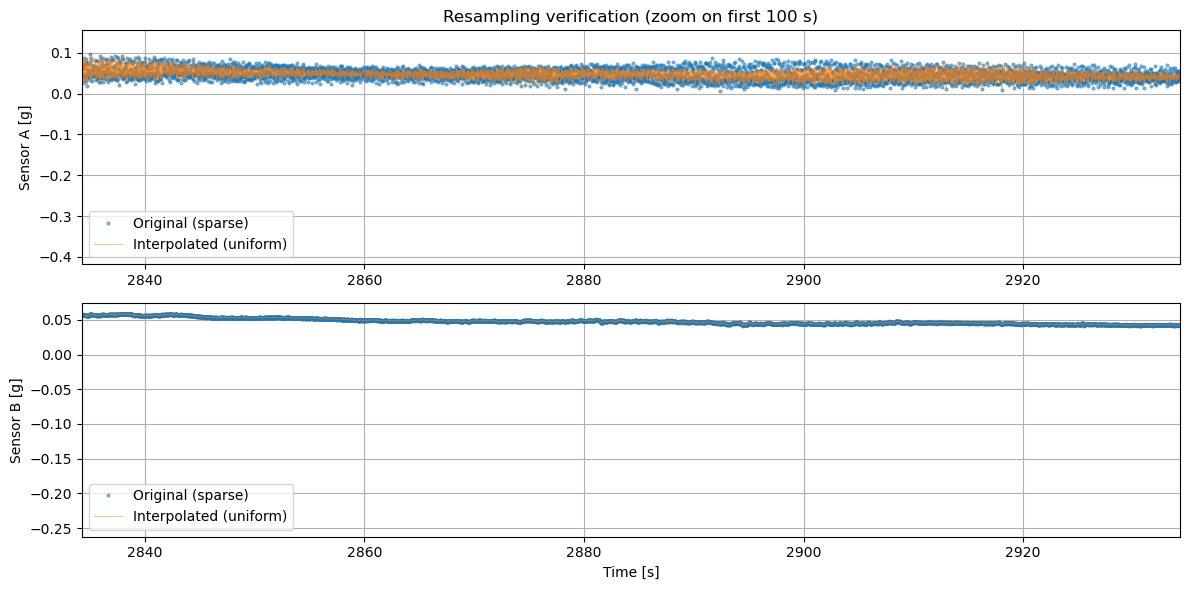


✓ Uniform resampling complete. Use t_u, a1_u, a2_u for all subsequent analysis.


In [19]:

# Build a uniform time base using the median dt
t_u = np.arange(t[0], t[-1] + dt_med/2, dt_med)  # uniform grid
fs = 1.0 / dt_med  # Store for later use (CRITICAL)

# Interpolate both accelerometers onto the uniform grid
a1_u = np.interp(t_u, t, df[a1_col].to_numpy())
a2_u = np.interp(t_u, t, df[a2_col].to_numpy())

print("Uniform Resampling")
print("="*60)
print(f"Original samples: {len(t)}")
print(f"Uniform samples:  {len(t_u)}")
print(f"Sample rate: fs = {fs:.3f} Hz (fixed)")
print(f"Total duration: {t_u[-1] - t_u[0]:.1f} s")

# Quick visual check of interpolation quality
fig, axs = plt.subplots(2, 1, figsize=(12, 6))
# Plot Sensor A
axs[0].plot(t, df[a1_col], 'o', markersize=2, alpha=0.5, label='Original (sparse)')
axs[0].plot(t_u, a1_u, '-', linewidth=0.5, label='Interpolated (uniform)', alpha=0.7)
axs[0].set_ylabel('Sensor A [g]')
axs[0].set_title('Resampling verification (zoom on first 100 s)')
axs[0].legend()
axs[0].set_xlim(t[0], t[0]+100)

# Plot Sensor B
axs[1].plot(t, df[a2_col], 'o', markersize=2, alpha=0.5, label='Original (sparse)')
axs[1].plot(t_u, a2_u, '-', linewidth=0.5, label='Interpolated (uniform)', alpha=0.7)
axs[1].set_xlabel('Time [s]')
axs[1].set_ylabel('Sensor B [g]')
axs[1].legend()
axs[1].set_xlim(t[0], t[0]+100)
plt.tight_layout()
plt.show()

# Going forward, use t_u, a1_u, a2_u (the uniform-sampled versions)
print("\n✓ Uniform resampling complete. Use t_u, a1_u, a2_u for all subsequent analysis.")


## 4) Touchdown Localisation from Accelerometers

Detecting touchdown from longitudinal acceleration alone is inherently ambiguous. A simple amplitude-based rule — selecting the global maximum of |z| on a detrended proxy — is useful as a quick baseline but has well-documented limitations:

- The largest pulse is not necessarily the **first** wheel–runway contact. It may correspond to a subsequent resonance, nose-gear slap, or a braking/reverse-thrust pulse occurring later during rollout (see FAA AC 91-79A, p. 25).
- Touchdown typically presents as a **short-lived, frequency-localised signature**. Methods that emphasise signal onset and band-limited energy (e.g., wavelet detectors, change-point approaches) are more robust than amplitude peaks, particularly for smooth landings ([MDPI Sensors, 2020](https://www.mdpi.com/1424-8220/20/24/7231)).
- In operational FDM, touchdown is inferred from **combined** parameters — radio altitude (RA), vertical/longitudinal acceleration, Weight on Wheels (WoW) — because any single channel can be ambiguous ([EASA ATR FDM, 2016](https://www.easa.europa.eu/sites/default/files/dfu/16T0153_ATR_FDM_2016.pdf)).

The two sharp spikes near ≈ 3331.5–3332 s are the credible main-gear contact candidates, while the broader trough around ≈ 3337 s is more consistent with on-ground deceleration during rollout. The amplitude-based detector is therefore treated as a **provisional** estimate, to be refined via RBF change-point detection in Part 2.


### 4a) Accelerometer-Based Touchdown Detection

Four complementary views are produced:
- **Figure 1** — full record overview to contextualise the landing event within the 8-minute log.
- **Figure 2** — the combined proxy signal (Sensor A + Sensor B), which emphasises excitations common to both sensors.
- **Figure 3** — the detrended, z-scored proxy. Detrending removes slow drift; z-scoring expresses deviations in σ units, making |z| a simple threshold-free peak detector.
- **Figure 4** — ±30 s zoom around the detected instant for visual validation.

The known limitation of the global |z| rule is that it may select the deepest trough — biased late by the width of the rollout transient — rather than the earliest onset of main-gear contact. This motivates the CPD-based refinement in Part 2.


Touchdown Detection (Accelerations Only)
Estimated touchdown index: 24512
Estimated touchdown time:  3336.78 s
Relative to start: 502.5 s into the 517.1 s record


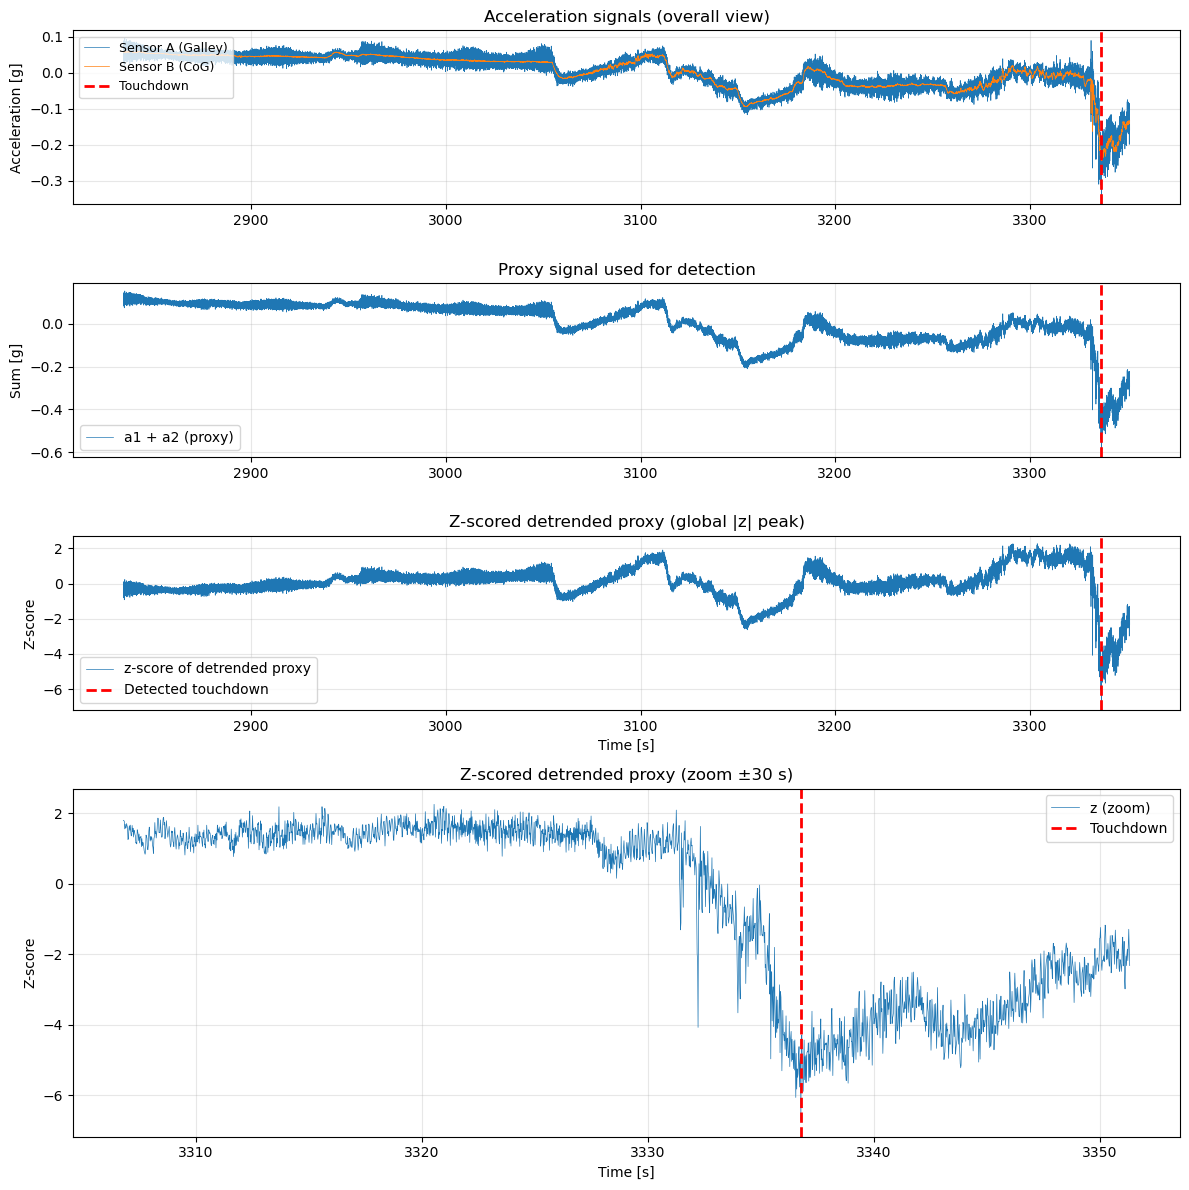


✓ Touchdown located at t = 3336.78 s (store for windows and later CPD comparison).


In [20]:
# 4a — Touchdown detection (detector only)


# Build proxy from both sensors, detrend, z-score
ax   = a1_u + a2_u                                   # proxy: combine sensors
ax_d = signal.detrend(ax, type='linear')             # remove slow drift
z    = (ax_d - np.mean(ax_d)) / (np.std(ax_d) + 1e-12)  # unitless

# Touchdown = global peak magnitude of z
idx_touch = np.argmax(np.abs(z))
t_touch   = t_u[idx_touch]

print("Touchdown Detection (Accelerations Only)")
print("="*60)
print(f"Estimated touchdown index: {idx_touch}")
print(f"Estimated touchdown time:  {t_touch:.2f} s")
print(f"Relative to start: {t_touch - t_u[0]:.1f} s into the {t_u[-1]-t_u[0]:.1f} s record")

# Plots: overall view, proxy, z-scored proxy, and a zoom around touchdown
fig, axs = plt.subplots(4, 1, figsize=(12, 12), sharex=False, gridspec_kw={'height_ratios': [1, 1, 1, 2]})


# 1) Overall accelerations
axs[0].plot(t_u, a1_u, linewidth=0.5, label='Sensor A (Galley)')
axs[0].plot(t_u, a2_u, linewidth=0.5, label='Sensor B (CoG)')
axs[0].axvline(t_touch, color='r', linestyle='--', linewidth=2, label='Touchdown')
axs[0].set_ylabel('Acceleration [g]')
axs[0].set_title('Acceleration signals (overall view)')
axs[0].legend(loc='upper left', fontsize=9)
axs[0].grid(True, which='both', alpha=0.3)

# 2) Proxy used for detection
axs[1].plot(t_u, ax, linewidth=0.5, label='a1 + a2 (proxy)')
axs[1].axvline(t_touch, color='r', linestyle='--', linewidth=2)
axs[1].set_ylabel('Sum [g]')
axs[1].set_title('Proxy signal used for detection')
axs[1].grid(True, which='both', alpha=0.3)
axs[1].legend()

# 3) Z-scored detrended proxy
axs[2].plot(t_u, z, linewidth=0.5, label='z-score of detrended proxy')
axs[2].axvline(t_touch, color='r', linestyle='--', linewidth=2, label='Detected touchdown')
axs[2].set_xlabel('Time [s]')
axs[2].set_ylabel('Z-score')
axs[2].set_title('Z-scored detrended proxy (global |z| peak)')
axs[2].grid(True, which='both', alpha=0.3)
axs[2].legend()

# 4) Zoomed z-score around touchdown (±50 s)
zoom_mask = (t_u >= t_touch - 30.0) & (t_u <= t_touch + 30.0)
axs[3].plot(t_u[zoom_mask], z[zoom_mask], linewidth=0.5, label='z (zoom)')
axs[3].axvline(t_touch, color='r', linestyle='--', linewidth=2, label='Touchdown')
axs[3].set_xlabel('Time [s]')
axs[3].set_ylabel('Z-score')
axs[3].set_title('Z-scored detrended proxy (zoom ±30 s)')
axs[3].grid(True, which='both', alpha=0.3)
axs[3].legend()

plt.tight_layout()
plt.show()

print(f"\n✓ Touchdown located at t = {t_touch:.2f} s (store for windows and later CPD comparison).")


### 4b) Post-Touchdown Analysis Window

Welch's method assumes quasi-stationarity. The transient around touchdown violates this, so a bilateral exclusion band of ±5 s is applied, and only the rollout segment that follows is used for all spectral estimates.

`W_post` sets the length of the post-touchdown window. If the requested duration extends past the end of the recording, the window is truncated to the available data, and the effective length `T_post` is printed for reference. All downstream spectral calculations use `post_mask`.

**Note on window placement:** because the amplitude-based detector may be late relative to true first contact, the exclusion band is likely mis-centred — removing part of the rollout rather than the touchdown transient itself. This shortens the effective post-window and reduces the number of Welch averages, inflating PSD variance slightly.


Analysis Window (Post-touchdown only)
Post-touchdown:    467 samples  (   9.6 s)
Exclusion band:  ±5.0 s (not included in spectra)
Post window start: 3341.78 s, end: 3351.34 s, length: 9.6 s


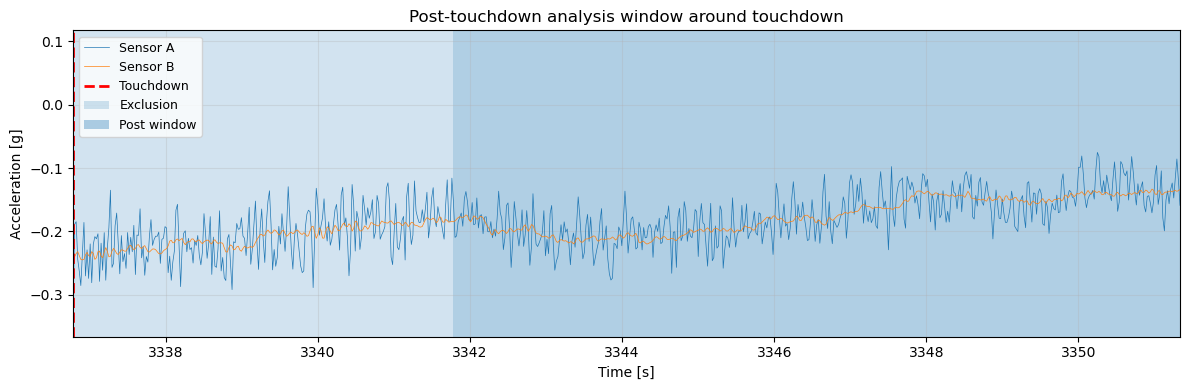


✓ This post_mask will be automatically used for all PSD/coherence/spectral-ratio/spectrogram computations.


In [21]:
# 4b — Define analysis window for PSD/coherence (post-touchdown only)

# Analysis window parameters
W_post           = 120.0  # seconds after touchdown (starts at t_touch + exclusion_window)
exclusion_window = 5.0    # exclude ±5 s around touchdown (non-stationary transient)


# Post-touchdown mask for quasi-stationary analysis (does not affect detection)
post_mask = (t_u >= t_touch + exclusion_window) & (t_u <= t_touch + W_post)

N_post = int(np.sum(post_mask))
T_post = N_post / fs

print("Analysis Window (Post-touchdown only)")
print("="*60)
print(f"Post-touchdown:  {N_post:5d} samples  ({T_post:6.1f} s)")
print(f"Exclusion band:  ±{exclusion_window:.1f} s (not included in spectra)")

# Visual confirmation of the mask around touchdown
fig, ax = plt.subplots(1, 1, figsize=(12, 4))
ax.plot(t_u, a1_u, linewidth=0.5, label='Sensor A')
ax.plot(t_u, a2_u, linewidth=0.5, label='Sensor B')
ax.axvline(t_touch, color='r', linestyle='--', linewidth=2, label='Touchdown')
ax.axvspan(t_touch - exclusion_window, t_touch + exclusion_window, alpha=0.2, label='Exclusion')

# Compute explicit post-window bounds (clamped to data)
t0_post = float(max(t_touch + exclusion_window, t_u[0]))
t1_post = float(min(t_touch + W_post,         t_u[-1]))

# Shade the post window
if t1_post > t0_post:
    ax.axvspan(t0_post, t1_post, alpha=0.35, label='Post window', zorder=0)

# Clamp x-limits around the actual post window with small padding
left_lim  = max(float(t_u[0]),  t0_post - 5.0)
right_lim = min(float(t_u[-1]), t1_post + 5.0)
ax.set_xlim(left_lim, right_lim)

# (Optional) print the exact post-window bounds for your brief
print(f"Post window start: {t0_post:.2f} s, end: {t1_post:.2f} s, length: {t1_post - t0_post:.1f} s")


ax.set_ylabel('Acceleration [g]')
ax.set_xlabel('Time [s]')
ax.set_title('Post-touchdown analysis window around touchdown')
ax.grid(True, which='both', alpha=0.3)
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

print("\n✓ This post_mask will be automatically used for all PSD/coherence/spectral-ratio/spectrogram computations.")


**Note on the exclusion window**

Because the detector relies on the global |z| peak, which tends to be biased late (it captures the maximum-magnitude excursion rather than the earliest onset), the ±5 s exclusion band may in practice cut into the early rollout rather than the true touchdown transient. In this dataset the detected time falls close to the correct interval, but for smoother landings or noisier signals the bias would be more significant — which is precisely why Part 2 uses a change-point approach anchored on radio altitude.


## 5) Welch Parameter Helper Function

The helper `pick_welch_params` computes a single consistent set of Welch parameters from the data length and the configuration values set in Section 1. It implements the following logic:

- Start from the target segment length (`TARGET_SEG_S × fs` samples).
- Cap by the minimum-segments constraint to guarantee sufficient averaging (`N // MIN_SEGMENTS`).
- Apply safety bounds (`MIN_NPERSEG` floor, `N` ceiling).
- Set `noverlap = nperseg // 2` (50% overlap, standard for Hann-windowed Welch).
- Round `nfft` up to the next power of two for efficient FFT computation.

The returned `nperseg`, `noverlap`, and `nfft` are reused verbatim across PSD, coherence, spectral ratio, and spectrogram — no per-plot tuning.


In [22]:
def pick_welch_params(fs, N, target_seg_s, min_segments, min_nperseg):
    """
    Choose Welch parameters that guarantee multiple segments with reasonable resolution.
    
    Parameters:
    -----------
    fs : float
        Sample rate (Hz).
    N : int
        Number of data points in the analysis window.
    target_seg_s : float, optional
        Target length (seconds) per segment. Default: 8.0 s.
        Smaller target → shorter segments → more averages (lower PSD variance) but coarser resolution.
    min_segments : int, optional
        Minimum number of segments required. Default: 8.
        Enforces a lower bound on variance reduction.
    min_nperseg : int, optional
        Minimum samples per segment. Default: 128.
        Enforces a lower bound on frequency resolution.
    
    Returns:
    --------
    nperseg : int
        Samples per segment.
    noverlap : int
        Samples of overlap (50% overlap).
    nfft : int
        FFT size (next power-of-2 ≥ nperseg for efficient computation).
    """
    # Start from target seconds per segment
    nperseg = int(target_seg_s * fs)
    
    # Cap by how many segments we can form with min_segments constraint
    max_by_segments = max(min_nperseg, N // max(1, min_segments))
    nperseg = min(nperseg, max_by_segments, N)
    
    # Final safety clamps
    nperseg = max(64, min(nperseg, N))
    noverlap = nperseg // 2
    nfft = 1 << int(np.ceil(np.log2(nperseg)))  # next power-of-2
    
    return nperseg, noverlap, nfft

print("✓ Helper function defined.")

✓ Helper function defined.


### Spectral Analysis — Methodological Principles

- **Post-touchdown segment only.** All spectral estimates are computed on `post_mask`; the pre-touchdown approach and the touchdown transient itself are excluded.
- **Single parameter set.** The helper-derived `nperseg`, `noverlap`, `nfft`, and Hann window are applied identically to PSD, coherence, spectral ratio, and spectrogram, ensuring full comparability.
- **Uncertainty-aware interpretation.** With a short post-window, PSD standard deviation scales as ≈ 1/√(segments). Band-level statements are therefore preferred over single-bin claims.
- **No FRF or causality claims.** With two outputs and no known input, the ratio and coherence are comparative descriptors only; they do not constitute a frequency response function.
- **Frequency range capped at Nyquist** (`fs/2`).


## 6) Welch PSD — Post-Touchdown

Power spectral densities are estimated with Welch's method (Hann window, 50% overlap) on the post-touchdown rollout. The parameters are taken directly from the helper function, and the plot title reports the key figures (`nperseg`, number of segments, Δf) for reproducibility.

The analysis focuses on the physically meaningful band below 25 Hz. Spectral features above Nyquist are not plotted. Given the short window, broad-band trends and multi-bin peaks are more meaningful than individual narrow spikes.


POST-TOUCHDOWN WELCH PSD – PARAMETER SUMMARY

Window size:
  Duration: 9.6 s (467 samples)

Welch parameters (from helper function):
  nperseg:    128 samples (~2.62 s per segment)
  noverlap:    64 samples (50% overlap)
  nfft:       128 samples (next power-of-2 for FFT)

Resolution and averaging:
  Frequency resolution: Δf = fs / nperseg = 48.78 / 128 = 0.3811 Hz
  Number of segments: ~6
  Effective averages: ~6 (PSD stdev scales ≈ 1/√6)

PSD computed. Frequency range: 0.000 to 24.4 Hz
Number of frequency bins: 65


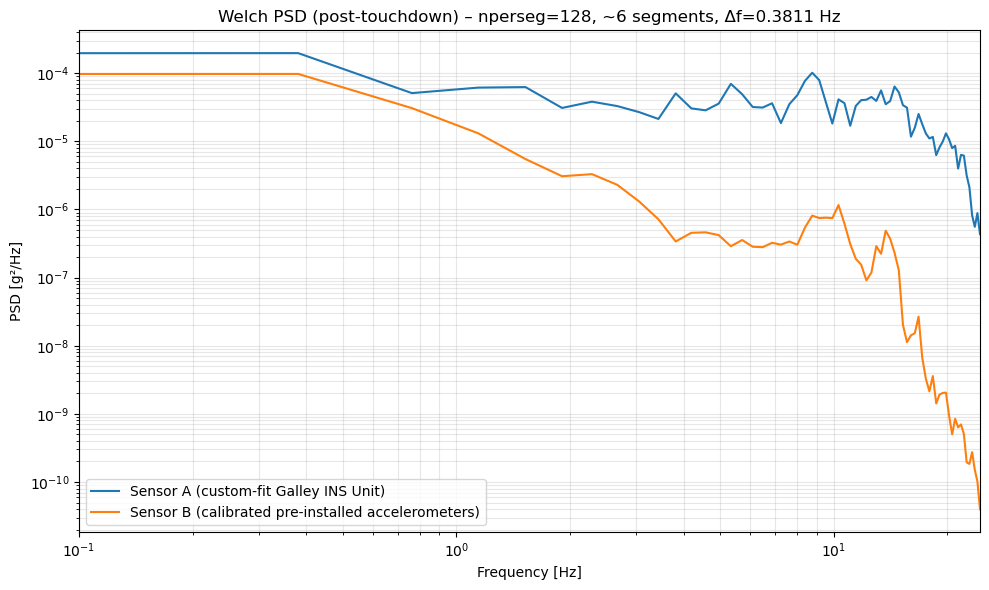


✓ Post-touchdown PSD computed and stored.


In [23]:
# Extract post-touchdown slice
xA_post = a1_u[post_mask]  # Sensor A (Galley/custom-fit INS)
xB_post = a2_u[post_mask]  # Sensor B (CoG/calibrated pre-installed)

N_post_actual = len(xA_post)

# Get Welch parameters using helper – DO NOT MODIFY THESE MANUALLY
nperseg, noverlap, nfft = pick_welch_params(fs, N_post_actual, 
                                              TARGET_SEG_S, 
                                              MIN_SEGMENTS, 
                                              MIN_NPERSEG)


# Compute derived parameters for reporting
delta_f = fs / nperseg
n_segments = max(1, (N_post_actual - noverlap) // (nperseg - noverlap))

print("POST-TOUCHDOWN WELCH PSD – PARAMETER SUMMARY")
print("="*60)
print(f"\nWindow size:")
print(f"  Duration: {T_post:.1f} s ({N_post_actual} samples)")
print(f"\nWelch parameters (from helper function):")
print(f"  nperseg:  {nperseg:5d} samples (~{nperseg/fs:.2f} s per segment)")
print(f"  noverlap: {noverlap:5d} samples (50% overlap)")
print(f"  nfft:     {nfft:5d} samples (next power-of-2 for FFT)")
print(f"\nResolution and averaging:")
print(f"  Frequency resolution: Δf = fs / nperseg = {fs:.2f} / {nperseg} = {delta_f:.4f} Hz")
print(f"  Number of segments: ~{n_segments}")
print(f"  Effective averages: ~{n_segments} (PSD stdev scales ≈ 1/√{n_segments:.0f})")


# Compute PSDs using scipy.signal.welch with Hann window
f_post, P_post_A = signal.welch(xA_post, fs=fs, window='hann', nperseg=nperseg, 
                                 noverlap=noverlap, nfft=nfft, detrend='constant', 
                                 scaling='density')
f_, P_post_B = signal.welch(xB_post, fs=fs, window='hann', nperseg=nperseg, 
                           noverlap=noverlap, nfft=nfft, detrend='constant', 
                           scaling='density')

print(f"\nPSD computed. Frequency range: {f_post[0]:.3f} to {f_post[-1]:.1f} Hz")
print(f"Number of frequency bins: {len(f_post)}")

# Plot
plt.figure(figsize=(10, 6))
plt.loglog(f_post, P_post_A, label='Sensor A (custom-fit Galley INS Unit)', linewidth=1.5)
plt.loglog(f_post, P_post_B, label='Sensor B (calibrated pre-installed accelerometers)', linewidth=1.5)
plt.xlabel('Frequency [Hz]')
plt.ylabel('PSD [g²/Hz]')
plt.title(f'Welch PSD (post-touchdown) – nperseg={nperseg}, ~{n_segments} segments, Δf={delta_f:.4f} Hz')
plt.xlim(0.1, min(25, fs/2))  # focus on physically meaningful band
#plt.ylim(1e-5, 1)  # adjust to your data
plt.legend(loc='lower left')
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

# Store for later use (coherence, ratio, band-limited RMS)
print(f"\n✓ Post-touchdown PSD computed and stored.")


In [24]:
# Parameter report (auto) — include in brief
delta_f = fs / nperseg
segments_est = max(1, (len(xA_post) - noverlap)//max(1, (nperseg - noverlap)))
print(f'Welch: window=Hann, nperseg={nperseg}, noverlap={noverlap}, nfft={nfft}, Δf={delta_f:.4f} Hz, segments≈{segments_est}')
print(f'Windows: post={W_post:.1f}s, exclusion ±{exclusion_window:.0f} s')


Welch: window=Hann, nperseg=128, noverlap=64, nfft=128, Δf=0.3811 Hz, segments≈6
Windows: post=120.0s, exclusion ±5 s


**Spectral Parameter Rationale**

The post-touchdown window of `T_post` seconds, combined with the sampling rate `fs`, constrains how large `nperseg` can be before the number of Welch segments drops below a meaningful threshold. The chosen `TARGET_SEG_S = 8 s` gives `nperseg ≈ 8 × fs` samples per segment, capped so that at least `MIN_SEGMENTS` non-overlapping half-segments are available.

- **Hann window:** minimises spectral leakage at the cost of a slightly wider main lobe relative to a rectangular window — the right trade-off for broadband vibration data.
- **50% overlap:** recovers most of the statistical efficiency lost by windowing, approximately doubling the effective number of independent estimates at a given `nperseg`.
- **`detrend='constant'`:** the post-touchdown segment shows no significant low-frequency ramp, so mean-subtraction is sufficient; polynomial detrending is not warranted.
- **Frequency resolution Δf = fs / nperseg:** with the default settings this is ≈ 0.38 Hz. Features narrower than Δf cannot be resolved; band-level RMS (Section 9) is therefore the primary quantitative metric.


## 7) Inter-Sensor Coherence — Post-Touchdown

Magnitude-squared coherence quantifies the linear correlation between the two sensors as a function of frequency. Values close to 1 indicate **shared, linearly coupled excitations** — structural or aerodynamic modes that both sensors observe equally. Values below 0.3 suggest **uncorrelated or sensor-local content**.

The same Welch parameters as Section 6 are used to ensure that the coherence and PSD estimates are directly comparable. Two indicative thresholds (0.7 and 0.3) are marked for interpretation, though these are heuristic rather than hard boundaries.

**Caveat:** coherence measures linear coupling under the ambient excitation; it does not imply a causal relationship or allow derivation of a transfer function from two output-only measurements.


POST-TOUCHDOWN COHERENCE ANALYSIS

High coherence (>0.7) detected at frequencies:
  ~0.4 Hz
  ~24.0 Hz

Low coherence (<0.3) detected at frequencies:
  ~0.8 Hz
  ~1.1 Hz
  ~1.5 Hz
  ~1.9 Hz
  ~2.3 Hz
  ~2.7 Hz
  ~3.4 Hz
  ~3.8 Hz
  ~5.3 Hz
  ~6.9 Hz


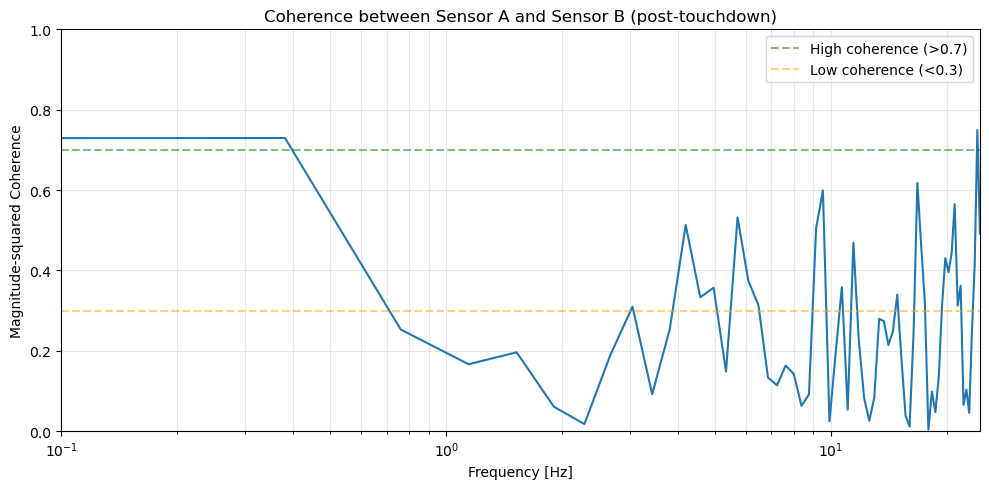


✓ Coherence analysis complete.


In [25]:
# Compute magnitude-squared coherence using THE SAME parameters

fC_post, Cxy_post = signal.coherence(
    xA_post, xB_post, fs=fs, window='hann',
    nperseg=nperseg, noverlap=noverlap, nfft=nfft, detrend='constant'
)


print("POST-TOUCHDOWN COHERENCE ANALYSIS")
print("="*60)

# Identify high and low coherence bands
high_coh = fC_post[(Cxy_post > 0.7) & (fC_post < 25)]
low_coh = fC_post[(Cxy_post < 0.3) & (fC_post < 25) & (fC_post > 0.1)]

if len(high_coh) > 0:
    print(f"\nHigh coherence (>0.7) detected at frequencies:")
    coh_high_unique = np.unique(high_coh.round(1))
    for f_val in coh_high_unique[:10]:  # Print first 10
        print(f"  ~{f_val:.1f} Hz")
else:
    print(f"\nNo high coherence (>0.7) bands in 0.1–25 Hz.")

if len(low_coh) > 0:
    print(f"\nLow coherence (<0.3) detected at frequencies:")
    coh_low_unique = np.unique(low_coh.round(1))
    for f_val in coh_low_unique[:10]:  # Print first 10
        print(f"  ~{f_val:.1f} Hz")
else:
    print(f"\nNo low coherence (<0.3) bands in 0.1–25 Hz.")

# Plot
plt.figure(figsize=(10, 5))
plt.semilogx(fC_post, Cxy_post, linewidth=1.5)
plt.axhline(0.7, color='g', linestyle='--', alpha=0.5, label='High coherence (>0.7)')
plt.axhline(0.3, color='orange', linestyle='--', alpha=0.5, label='Low coherence (<0.3)')
plt.ylim(0, 1)
plt.xlim(0.1, min(25, fs/2))
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude-squared Coherence')
plt.title('Coherence between Sensor A and Sensor B (post-touchdown)')
plt.legend()
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n✓ Coherence analysis complete.")


## 8) Spectral Ratio (Sensor A / Sensor B) — Post-Touchdown

The spectral ratio P_A / P_B highlights frequency bands where the galley-mounted Sensor A carries more (or less) energy than the CoG Sensor B. This is a **comparative energy map**, not a transfer function — the input excitation is unknown, so the ratio reflects both structural dynamics and the excitation spectrum.

Interpretation follows a cross-reference logic:
- **High ratio + low coherence (<0.3):** energy likely local to Sensor A (e.g., cabinet resonance, mounting effect).
- **High ratio + high coherence (>0.7):** shared excitation reaching Sensor A at a higher level, possibly due to its position in the fuselage.

Ratios are expressed both in linear form and in dB (10·log₁₀), where +3 dB ≈ 2× power and +10 dB ≈ 10× power. Single-bin extremes in the high-frequency tail (where PSD rolls off sharply) are treated with caution and confirmed against band-limited RMS.


POST-TOUCHDOWN SPECTRAL RATIO ANALYSIS

Ratio = P_A (Sensor A) / P_B (Sensor B)
Linear ratio > 1 ⟹ Sensor A higher (local amplification or coupling)
Linear ratio < 1 ⟹ Sensor B higher (local amplification or coupling)

Convert to dB: 10*log10(ratio) dB
  +3 dB ≈ 2× power
   +10 dB ≈ 10× power
  0 dB ≈ equal

Bands where Sensor A > 6 dB above Sensor B (≈4× power):
  ~1.1 Hz
  ~1.5 Hz
  ~1.9 Hz
  ~2.3 Hz
  ~2.7 Hz
  ~3.0 Hz
  ~3.4 Hz
  ~3.8 Hz
  ~4.2 Hz
  ~4.6 Hz


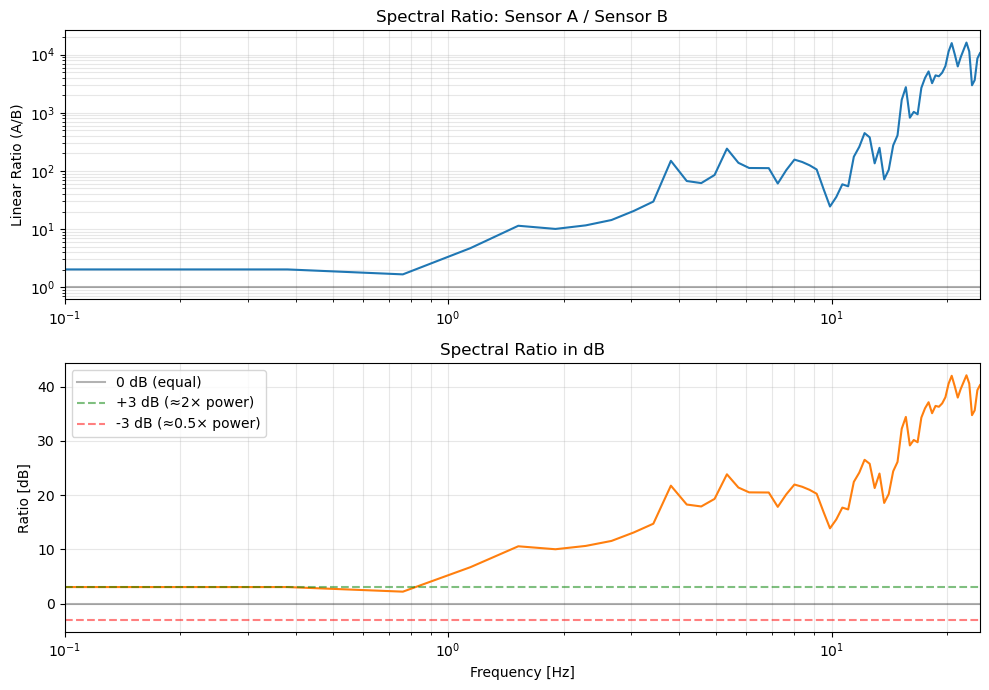


✓ Spectral ratio analysis complete.


In [26]:
ratio_post = P_post_A / (P_post_B + 1e-12)  # small constant to avoid division by zero

print("POST-TOUCHDOWN SPECTRAL RATIO ANALYSIS")
print("="*60)
print(f"\nRatio = P_A (Sensor A) / P_B (Sensor B)")
print(f"Linear ratio > 1 ⟹ Sensor A higher (local amplification or coupling)")
print(f"Linear ratio < 1 ⟹ Sensor B higher (local amplification or coupling)")
print(f"\nConvert to dB: 10*log10(ratio) dB")
print(f"  +3 dB ≈ 2× power")
print(f"   +10 dB ≈ 10× power")
print(f"  0 dB ≈ equal")

ratio_dB = 10 * np.log10(ratio_post + 1e-12)

# Identify prominent bands
high_ratio_freqs = f_post[(ratio_dB > 6) & (f_post < 25)]
if len(high_ratio_freqs) > 0:
    high_ratio_unique = np.unique(high_ratio_freqs.round(1))
    print(f"\nBands where Sensor A > 6 dB above Sensor B (≈4× power):")
    for f_val in high_ratio_unique[:10]:  # First 10
        print(f"  ~{f_val:.1f} Hz")

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7))

# Linear scale
ax1.semilogx(f_post, ratio_post, linewidth=1.5)
ax1.set_ylabel('Linear Ratio (A/B)')
ax1.set_title('Spectral Ratio: Sensor A / Sensor B')
ax1.axhline(1, color='k', linestyle='-', alpha=0.3)
ax1.set_xlim(0.1, min(25, fs/2))


ax1.set_yscale('log')
ax1.grid(True, which='both', alpha=0.3)

# dB scale
ax2.semilogx(f_post, ratio_dB, linewidth=1.5, color='C1')
ax2.axhline(0, color='k', linestyle='-',  alpha=0.3, label='0 dB (equal)')
ax2.axhline(3, color='g', linestyle='--', alpha=0.5, label='+3 dB (≈2× power)')
ax2.axhline(-3, color='r', linestyle='--', alpha=0.5, label='-3 dB (≈0.5× power)')

ax2.set_xlabel('Frequency [Hz]')
ax2.set_ylabel('Ratio [dB]')
ax2.set_title('Spectral Ratio in dB')
ax2.set_xlim(0.1, min(25, fs/2))
ax2.grid(True, which='both', alpha=0.3)
ax2.legend(loc='best')

plt.tight_layout()
plt.show()

print(f"\n✓ Spectral ratio analysis complete.")


## 9) Band-Limited RMS Analysis — Post-Touchdown

Integrating the Welch PSD over defined frequency bands converts spectral density into actionable vibration levels (g RMS). Three bands are defined based on the PSD and coherence findings:

- **Low band (0.1–2 Hz):** dominated by flight-mechanics / braking transients.
- **Mid band (2–10 Hz):** structural resonances of the fuselage and landing gear.
- **High band (10–25 Hz):** higher-order structural modes, local sensor effects.

The formula is: RMS = √(∫ PSD(f) df) over the band, computed via the trapezoidal rule on the Welch frequency grid.


In [27]:
# === DEFINE FREQUENCY BANDS ===
# Frequency bands defined from PSD and coherence inspection
bands = {
    'Low Freq (0.1–2 Hz)': (0.1, 2.0),
    'Mid Freq (2–10 Hz)': (2.0, 10.0),
    'High Freq (10–25 Hz)': (10.0, 25.0),
}

print("POST-TOUCHDOWN BAND-LIMITED RMS ANALYSIS")
print("="*60)
print(f"\nBands defined:")
for band_name, (f_low, f_high) in bands.items():
    print(f"  {band_name}: {f_low}–{f_high} Hz")
print(f"\nIntegrating PSD over each band to compute RMS...\n")

results_summary = []

for band_name, (f_low, f_high) in bands.items():
    # Find frequency indices within band
    mask = (f_post >= f_low) & (f_post <= f_high)
    
    # Integrate PSD to get variance, then take sqrt for RMS
    rms_A = np.sqrt(np.trapezoid(P_post_A[mask], f_post[mask]))
    rms_B = np.sqrt(np.trapezoid(P_post_B[mask], f_post[mask]))
    
    ratio_rms = rms_A / (rms_B + 1e-12)
    
    print(f"{band_name}:")
    print(f"  Sensor A: {rms_A:.6f} g RMS")
    print(f"  Sensor B: {rms_B:.6f} g RMS")
    print(f"  Ratio A/B: {ratio_rms:.2f}× (or {10*np.log10(ratio_rms):.1f} dB)")
    print()
    
    results_summary.append({
        'band': band_name,
        'f_low': f_low,
        'f_high': f_high,
        'rms_A': rms_A,
        'rms_B': rms_B,
        'ratio': ratio_rms
    })

# Create a summary table
df_summary = pd.DataFrame(results_summary)
print("\n" + "="*60)
print("SUMMARY TABLE")
print("="*60)
print(df_summary.to_string(index=False))

print(f"\n✓ Band-limited RMS analysis complete.")


POST-TOUCHDOWN BAND-LIMITED RMS ANALYSIS

Bands defined:
  Low Freq (0.1–2 Hz): 0.1–2.0 Hz
  Mid Freq (2–10 Hz): 2.0–10.0 Hz
  High Freq (10–25 Hz): 10.0–25.0 Hz

Integrating PSD over each band to compute RMS...

Low Freq (0.1–2 Hz):
  Sensor A: 0.010483 g RMS
  Sensor B: 0.006155 g RMS
  Ratio A/B: 1.70× (or 2.3 dB)

Mid Freq (2–10 Hz):
  Sensor A: 0.018183 g RMS
  Sensor B: 0.002255 g RMS
  Ratio A/B: 8.06× (or 9.1 dB)

High Freq (10–25 Hz):
  Sensor A: 0.017206 g RMS
  Sensor B: 0.001220 g RMS
  Ratio A/B: 14.10× (or 11.5 dB)


SUMMARY TABLE
                band  f_low  f_high    rms_A    rms_B     ratio
 Low Freq (0.1–2 Hz)    0.1     2.0 0.010483 0.006155  1.703043
  Mid Freq (2–10 Hz)    2.0    10.0 0.018183 0.002255  8.062647
High Freq (10–25 Hz)   10.0    25.0 0.017206 0.001220 14.103065

✓ Band-limited RMS analysis complete.


## 10) Time-Frequency Analysis — Spectrogram

The spectrogram shows how spectral power evolves over the post-touchdown rollout. The same `nperseg` and `noverlap` as the Welch PSD are used, so the time and frequency resolutions are consistent with all other spectral estimates.

The analysis looks for:
- **Persistent horizontal bands** — stable tonal content during rollout (e.g., gear-spin-down, persistent structural resonances).
- **Transient vertical features** — brief bursts or impulses (e.g., braking events, surface irregularities).
- **Temporal evolution** within the window — whether energy dissipates, builds, or shifts in frequency.

Colorbars on the two panels are independent; absolute level comparisons between sensors should rely on the PSD and band-RMS results rather than on colormap intensity.


SPECTROGRAM PARAMETERS
NFFT (window/nperseg): 128
Overlap: 64 samples (50%)
Frequency resolution: ~0.3811 Hz
Time resolution: ~2.62 s


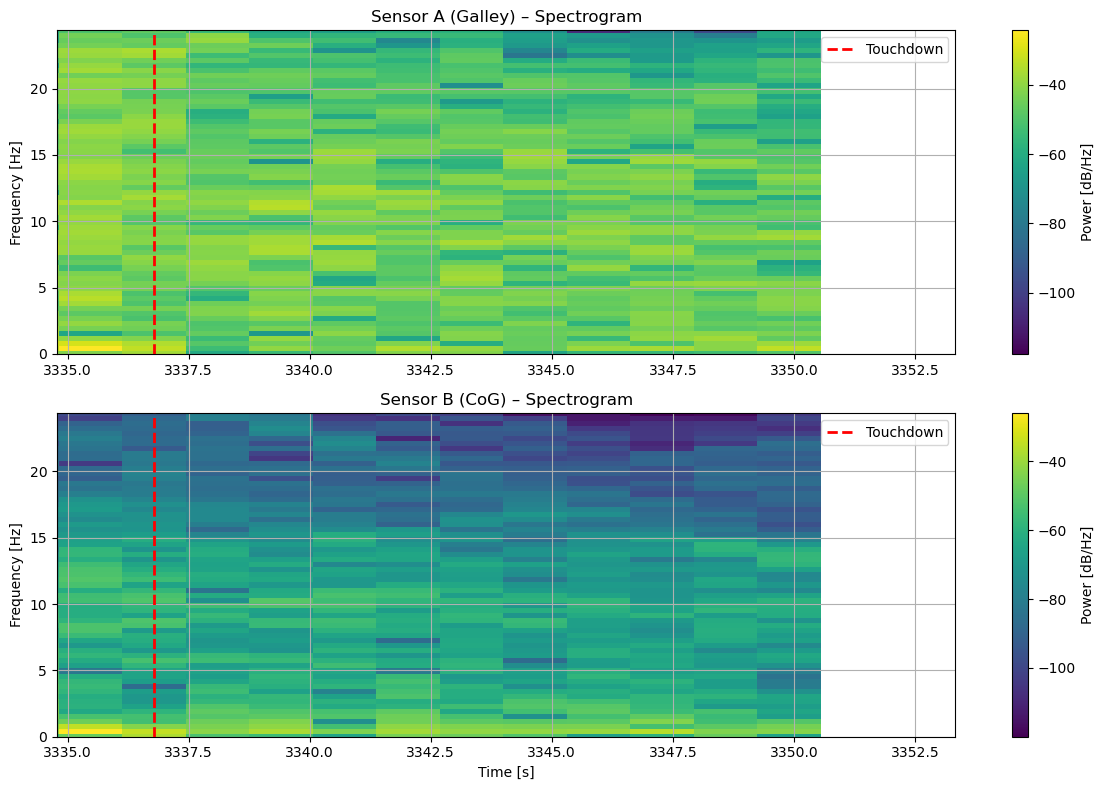


✓ Spectrograms generated and displayed.


In [28]:
# Use parameters similar to Welch for consistency
nperseg_tf = nperseg  # Use same window length as Welch
noverlap_tf = noverlap  # Use same overlap

print("SPECTROGRAM PARAMETERS")
print("="*60)
print(f"NFFT (window/nperseg): {nperseg_tf}")
print(f"Overlap: {noverlap_tf} samples (50%)")
print(f"Frequency resolution: ~{fs/nperseg_tf:.4f} Hz")
print(f"Time resolution: ~{nperseg_tf/fs:.2f} s")

# Spectrograms for full duration
fig, axs = plt.subplots(2, 1, figsize=(12, 8))

# Sensor A
f_spec_A, t_spec_A, Sxx_A = signal.spectrogram(a1_u, fs=fs, window='hann', 
                                                nperseg=nperseg_tf, noverlap=noverlap_tf,
                                                detrend='constant')
im_A = axs[0].pcolormesh(t_spec_A + t_u[0], f_spec_A, 10*np.log10(Sxx_A + 1e-12), 
                        shading='auto', cmap='viridis')
# Add zorder to ensure the line is plotted on top
axs[0].axvline(t_touch, color='r', linestyle='--', linewidth=2, label='Touchdown', zorder=5)
axs[0].set_ylabel('Frequency [Hz]')

# Clamp frequency axis to Nyquist
axs[0].set_ylim(0, min(30, fs/2))

axs[0].set_title('Sensor A (Galley) – Spectrogram')
axs[0].legend()
cbar_A = plt.colorbar(im_A, ax=axs[0])
cbar_A.set_label('Power [dB/Hz]')

# Sensor B
f_spec_B, t_spec_B, Sxx_B = signal.spectrogram(a2_u, fs=fs, window='hann', 
                                                nperseg=nperseg_tf, noverlap=noverlap_tf,
                                                detrend='constant')
im_B = axs[1].pcolormesh(t_spec_B + t_u[0], f_spec_B, 10*np.log10(Sxx_B + 1e-12), 
                        shading='auto', cmap='viridis')
# Add zorder to ensure the line is plotted on top
axs[1].axvline(t_touch, color='r', linestyle='--', linewidth=2, label='Touchdown', zorder=5)
axs[1].set_xlabel('Time [s]')
axs[1].set_ylabel('Frequency [Hz]')

axs[1].set_ylim(0, min(30, fs/2))



# Keeping original logic for the end of the time window
t1_post = float(min(t_touch + W_post, t_u[-1]))

# Define the start time to be a few seconds before touchdown to ensure it's visible
time_before_touchdown = 2.0  # seconds
x_min = t_touch - time_before_touchdown


x_max = t1_post + 2.0
axs[0].set_xlim(x_min, x_max)
axs[1].set_xlim(x_min, x_max)



axs[1].set_title('Sensor B (CoG) – Spectrogram')
axs[1].legend()
cbar_B = plt.colorbar(im_B, ax=axs[1])
cbar_B.set_label('Power [dB/Hz]')

plt.tight_layout()
plt.show()

print(f"\n✓ Spectrograms generated and displayed.")


## 11) Provisional Touchdown Estimate

The accelerometer-based touchdown time is stored here. This figure will be compared against the RBF change-point estimate (Part 2), which incorporates radio altitude and additional FDR channels to refine and validate the timing.


In [29]:
print("\n" + "="*60)
print("PART 1 SUMMARY – TOUCHDOWN ESTIMATE")
print("="*60)
print(f"\nAcceleration-based touchdown (from z-score peak):")
print(f"  t_touch = {t_touch:.2f} s")
print(f"  Index: {idx_touch}")
print(f"\nThis value will be compared with Part 2 (RBF CPD on FDR parameters).")
print(f"\n→ In Part 2, you will pass PART1_TOUCHDOWN_S = {t_touch:.2f}")
print(f"→ The RBF method may refine this to a slightly different value based on radio altitude, ")
print(f"  normal acceleration, etc.")
print(f"\n" + "="*60)



PART 1 SUMMARY – TOUCHDOWN ESTIMATE

Acceleration-based touchdown (from z-score peak):
  t_touch = 3336.78 s
  Index: 24512

This value will be compared with Part 2 (RBF CPD on FDR parameters).

→ In Part 2, you will pass PART1_TOUCHDOWN_S = 3336.78
→ The RBF method may refine this to a slightly different value based on radio altitude, 
  normal acceleration, etc.



## 12) Analysis Notes

This section collects the key quantitative findings from the spectral analysis for use in the written summary.

**A. Provisional touchdown time**  
Record `t_touch` (s) from Section 4a and note it as an amplitude-peak estimate, to be compared with the CPD result.

**B. Spectral parameters**  
Copy from the parameter summary cell (Section 6): `fs`, `T_post`, `nperseg`, `noverlap`, `nfft`, `Δf`, number of segments.

**C. Coherence findings**  
Identify 2–3 frequency bands with coherence > 0.7 (globally coupled content) and 2–3 with coherence < 0.3 (sensor-local content).

**D. Band-limited RMS**  
For each of the three frequency bands: `RMS_A`, `RMS_B`, ratio A/B in dB.

**E. Spectral peaks**  
List 2–3 prominent features from the PSD as centre frequency ± Δf/2, with a note on coherence at those frequencies.

**F. Spectrogram observations**  
Note persistent bands vs. transient features, and whether both sensors show similar temporal evolution.

**G. Preliminary sensor reliability assessment**  
Based on PSD shape, coherence, and band-RMS: characterise the relative behaviour of Sensor A vs. Sensor B across the low, mid, and high bands. Avoid FRF or causality claims; keep statements consistent with the frequency resolution and number of averages.


## 13) Parameter Summary Table

A consolidated reference table of all analysis parameters, printed automatically from the values computed during the run. This serves as a reproducibility record.


In [30]:
# Create a parameter summary table
param_table = pd.DataFrame([
    {'Parameter': 'Sample rate (fs)', 'Value': f'{fs:.2f} Hz', 'Notes': 'From median dt'},
    {'Parameter': 'Total duration', 'Value': f'{t_u[-1]-t_u[0]:.1f} s', 'Notes': 'Full record'},
    {'Parameter': 'Post-touchdown window', 'Value': f'{T_post:.1f} s', 'Notes': f'After ±{exclusion_window} s exclusion'},
    {'Parameter': 'nperseg', 'Value': f'{nperseg}', 'Notes': 'From helper function'},
    {'Parameter': 'noverlap', 'Value': f'{noverlap}', 'Notes': '50% overlap'},
    {'Parameter': 'nfft', 'Value': f'{nfft}', 'Notes': 'Next power-of-2'},
    {'Parameter': 'Frequency resolution (Δf)', 'Value': f'{delta_f:.4f} Hz', 'Notes': 'fs / nperseg'},
    {'Parameter': '# segments averaged', 'Value': f'{n_segments}', 'Notes': 'Welch averages'},
    {'Parameter': 'Window type', 'Value': 'Hann', 'Notes': 'Fixed parameter'},
    {'Parameter': 'Detrend', 'Value': 'constant', 'Notes': 'Fixed parameter'},
    {'Parameter': 'Touchdown time (accel)', 'Value': f'{t_touch:.2f} s', 'Notes': 'To compare with Part 2 (RBF)'},
])

print("\n" + "="*80)
print("PARAMETER SUMMARY TABLE – PART 1")
print("="*80)
print(param_table.to_string(index=False))
print("\n" + "="*80)
print(f"\nThis table should be included in your report to demonstrate parameter choices.")



PARAMETER SUMMARY TABLE – PART 1
                Parameter     Value                        Notes
         Sample rate (fs)  48.78 Hz               From median dt
           Total duration   517.1 s                  Full record
    Post-touchdown window     9.6 s       After ±5.0 s exclusion
                  nperseg       128         From helper function
                 noverlap        64                  50% overlap
                     nfft       128              Next power-of-2
Frequency resolution (Δf) 0.3811 Hz                 fs / nperseg
      # segments averaged         6               Welch averages
              Window type      Hann              Fixed parameter
                  Detrend  constant              Fixed parameter
   Touchdown time (accel) 3336.78 s To compare with Part 2 (RBF)


This table should be included in your report to demonstrate parameter choices.


### Handoff to Change-Point Detection (Part 2)

The provisional touchdown time is exported to a text file for use in the Part 2 notebook, where it will be compared against the RBF CPD estimate derived from radio altitude and additional FDR parameters.


In [31]:
PART1_TOUCHDOWN_S = float(t_touch)
with open('part1_touchdown_seconds.txt', 'w') as f:
    f.write(f"{PART1_TOUCHDOWN_S:.6f}\n")
print(f"Saved: part1_touchdown_seconds.txt -> {PART1_TOUCHDOWN_S:.3f} s")


Saved: part1_touchdown_seconds.txt -> 3336.781 s


<details>
<summary><b>Appendix: Quick Reference </b></summary>

**Core definitions (used in this notebook)**
- `fs`: sample rate (Hz), from median Δt.
- `nperseg`:  samples per Welch segment (Hann window).
- `noverlap`:  overlap between segments (50% of `nperseg`).
- `nfft`:  FFT size (power-of-two ≥ `nperseg`).
- **Frequency resolution:** Δf = fs / nperseg.
- **#segments (approx.):** 1 + floor((N − nperseg) / (nperseg − noverlap)).
- **Coherence:** magnitude-squared coherence (0–1). Thresholds (0.7 / 0.3) are heuristics.
- **Spectral ratio (power):** A/B (linear), **dB = 10·log10(A/B)**.
  - +3 dB ≈ 2× power, +10 dB ≈ 10× power.

**Workflow recap (exactly what the notebook does)**
1. QA/QC → resample to uniform grid (`t_u`, `a1_u`, `a2_u`).
2. **Touchdown (provisional):** global |z| of detrended proxy; store `t_touch`.
3. **Post-touchdown mask only:** exclude ±`exclusion_window` around `t_touch`.
4. **One Welch parameter set** (from helper) → reuse for **PSD, coherence, ratio, spectrogram**.
5. **Band-limited RMS:** integrate PSD over chosen bands → RMS in g.

**Interpretation boundaries**
- Prefer **band-level** statements; avoid single-bin claims (short window ⇒ few averages).
- PSD/coherence are **comparative**; do **not** claim FRFs or causality from two outputs.
- Keep axes ≤ **Nyquist** (`fs/2`), as in the code.
- Uncertainty: PSD stdev scales ≈ **1/√(segments)**.

**Part-2 handoff**
- Export `t_touch` and compare with **RA + RBF CPD** in Part 2 to refine touchdown timing.

</details>
